Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6978 - val_loss: 0.7040 - learning_rate: 0.0100
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6821 - val_loss: 0.7036 - learning_rate: 0.0100
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6861 - val_loss: 0.6961 - learning_rate: 0.0100
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6845 - val_loss: 0.6990 - learning_rate: 0.0100
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6827 - val_loss: 0.6992 - learning_rate: 0.0100
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6809 - val_loss: 0.7043 - learning_rate: 0.0050
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6845 - val_loss: 0.7144 - learning_rate: 0.0050
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6792 - val_loss: 0.7176 - learning_rate: 0.0050
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6784 - val_loss: 0.7073 - learning_rate: 0.0050
Epoch 10/20
32/32 ━━━━━━━━━━

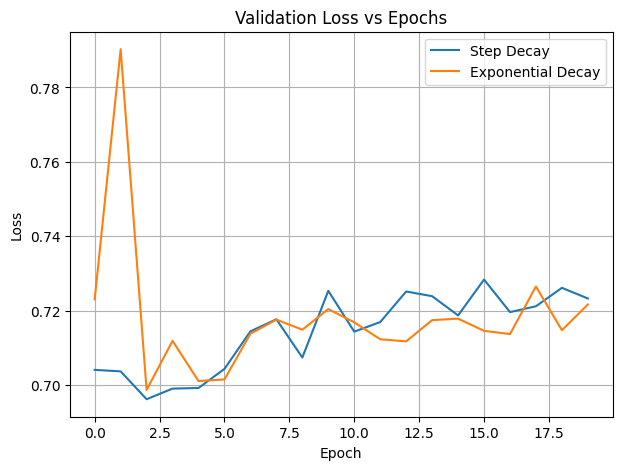

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt

# 1. Synthetic Data
x_train = np.random.random((1000, 20))
y_train = np.random.randint(0, 2, (1000,))
x_val = np.random.random((200, 20))
y_val = np.random.randint(0, 2, (200,))

# 2. Learning Rate Schedulers
def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    epochs_drop = 5
    return initial_lr * (drop ** (epoch // epochs_drop))

def exp_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    return initial_lr * np.exp(-k * epoch)

# 3. Training Function
def train_model(callback_list=None):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(20,)),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.01),
        loss='binary_crossentropy'
    )

    history = model.fit(
        x_train, y_train,
        epochs=20,
        validation_data=(x_val, y_val),
        callbacks=callback_list,
        verbose=1
    )

    return history.history['val_loss']

# 4. Train Models
results = {
    'Step Decay': train_model(
        [callbacks.LearningRateScheduler(step_decay)]
    ),
    'Exponential Decay': train_model(
        [callbacks.LearningRateScheduler(exp_decay)]
    )
}

# 5. Plot Validation Loss
plt.figure(figsize=(7, 5))

for name, loss in results.items():
    plt.plot(loss, label=name)

plt.title('Validation Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8075 - loss: 0.6645 - val_accuracy: 0.9492 - val_loss: 0.1713
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9557 - loss: 0.1507 - val_accuracy: 0.9633 - val_loss: 0.1197
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9708 - loss: 0.1014 - val_accuracy: 0.9681 - val_loss: 0.1042
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9777 - loss: 0.0731 - val_accuracy: 0.9738 - val_loss: 0.0876
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9819 - loss: 0.0571 - val_accuracy: 0.9752 - val_loss: 0.0840
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9862 - loss: 0.0435 - val_accuracy: 0.9748 - val_loss: 0.0805
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9893 - loss: 0.0356 - val_accuracy: 0.9775 - val_loss: 0.0758
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9917 - loss: 0.0275 - val_accuracy: 0.

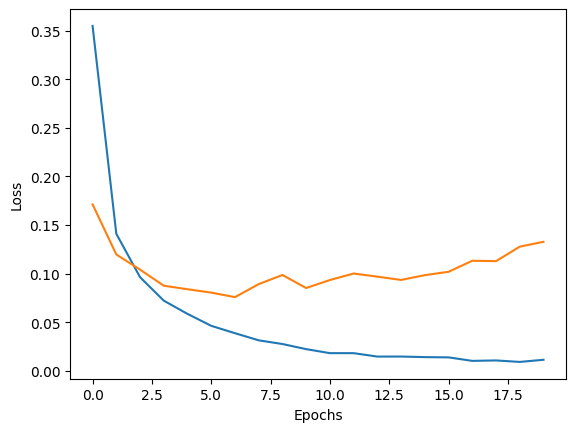

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.losses import CategoricalCrossentropy
from keras.datasets import mnist

(X_train,y_train),(X_test,y_test) = mnist.load_data()

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

model = Sequential()

model.add(Dense(128,activation='relu',input_shape = (784,)))

model.add(Dense(64,activation='relu'))

model.add(Dense(32,activation='relu'))

model.add(Dense(10,activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),metrics=['accuracy'],loss=CategoricalCrossentropy())

history = model.fit(X_train,y_train,epochs=20,batch_size=128,verbose=1,validation_data=(X_test,y_test))

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8604 - loss: 0.4381 - val_accuracy: 0.9528 - val_loss: 0.1626 - learning_rate: 0.0100
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9582 - loss: 0.1420 - val_accuracy: 0.9660 - val_loss: 0.1222 - learning_rate: 0.0100
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9697 - loss: 0.1043 - val_accuracy: 0.9655 - val_loss: 0.1290 - learning_rate: 0.0100
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9740 - loss: 0.0882 - val_accuracy: 0.9679 - val_loss: 0.1135 - learning_rate: 0.0100
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9789 - loss: 0.0742 - val_accuracy: 0.9662 - val_loss: 0.1271 - learning_rate: 0.0100
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9875 - loss: 0.0431 - val_accuracy: 0.9791 - val_loss: 0.0807 - learning_rate: 0.0010
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9923 - loss: 0.0260 - 

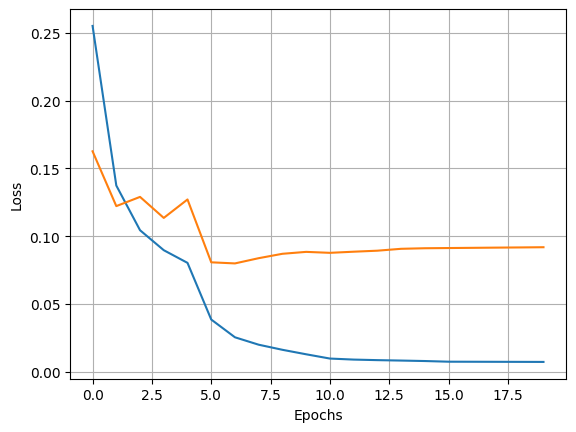

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.losses import CategoricalCrossentropy
from keras.datasets import mnist
from keras.callbacks import LearningRateScheduler

def step_decay(epoch):
  initial_lr = 0.01
  drop = 0.1
  epochs_drop = 5
  return initial_lr * (drop ** (epoch//epochs_drop))

(X_train,y_train),(X_test,y_test) = mnist.load_data()

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

model = Sequential()

model.add(Dense(128,activation='relu',input_shape = (784,)))

model.add(Dense(64,activation='relu'))

model.add(Dense(32,activation='relu'))

model.add(Dense(10,activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.01),metrics=['accuracy'],loss=CategoricalCrossentropy())

history = model.fit(X_train,y_train,epochs=20,batch_size=128,verbose=1,callbacks=[LearningRateScheduler(step_decay)],validation_data=(X_test,y_test))

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3656 - val_loss: 0.1210
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0914 - val_loss: 0.0836
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0542 - val_loss: 0.0737
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0295 - val_loss: 0.0659
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0193 - val_loss: 0.0665
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0132 - val_loss: 0.0660
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0097 - val_loss: 0.0661
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0077 - val_loss: 0.0668
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0068 - val_loss: 0.0675
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0068 - val_loss: 0.0681
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0057 - val_loss: 0.0681
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/

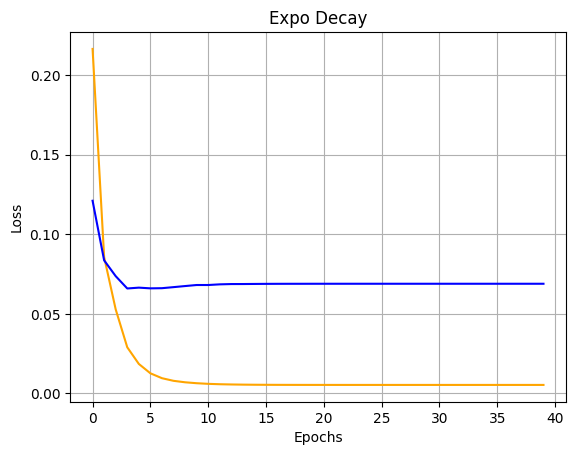

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.layers import Dense
from keras.callbacks import LearningRateScheduler
from keras.models import Sequential
from keras.optimizers import Adam
from keras.losses import categorical_crossentropy
from keras.datasets import mnist

(X_train,y_train),(X_test,y_test) = mnist.load_data()

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)

lr_schedule = keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=0.01,decay_steps=100,decay_rate=0.9)

model = Sequential()

model.add(Dense(128,activation='relu',input_shape=(784,)))

model.add(Dense(64,activation='relu'))

model.add(Dense(32,activation='relu'))

model.add(Dense(10,activation='softmax'))

model.compile(optimizer=Adam(learning_rate=lr_schedule),loss=categorical_crossentropy)

history = model.fit(X_train,y_train,epochs=40,batch_size=128,validation_data=(X_test,y_test))

plt.title("Expo Decay")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid(True)
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3592 - val_loss: 0.1306
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0935 - val_loss: 0.0898
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0510 - val_loss: 0.0792
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0329 - val_loss: 0.0692
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0193 - val_loss: 0.0704
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0131 - val_loss: 0.0699
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0100 - val_loss: 0.0717


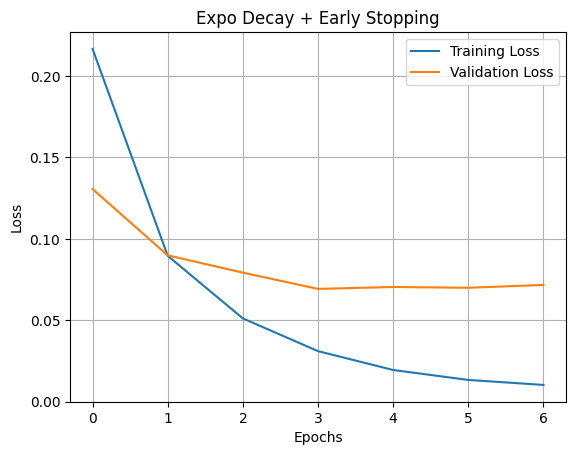

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential
from keras.optimizers import Adam
from keras.losses import categorical_crossentropy
from keras.datasets import mnist
from keras.callbacks import EarlyStopping

(X_train,y_train),(X_test,y_test) = mnist.load_data()

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=100,
    decay_rate=0.9
)

model = Sequential()

model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss=categorical_crossentropy
)

early_stop = EarlyStopping(
    monitor='val_loss',     # monitor validation loss
    patience=3,             # wait 3 epochs before stopping
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=128,
    validation_data=(X_test,y_test),
    callbacks=[early_stop]
)

plt.title("Expo Decay + Early Stopping")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.legend()
plt.grid(True)
plt.show()